In [25]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

file_path = '../Dataset/preprocessed_combined_data_weekday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0


In [26]:
X = df.drop('kW', axis = 1)
y = df.kW

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Split data into training and temporary data (80% training, 20% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary data into testing and validation sets (50% testing, 50% validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#Standardize features by removing the mean and scaling to unit variance
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



In [27]:
# # define the model
# # Experiment with deeper and wider networks

# # Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
# model = Sequential()

# # Dense layers (all connected) are added to the neural network with the specified neuron amount
# # 128 neurons in the 1st hidden layer 
# model.add(Dense(128, input_dim=18, activation='relu'))

# # 64 neurons in the 2nd hidden layer
# model.add(Dense(64, activation='relu'))

# # Output layer, linear activation function does nothing except adding the results of previous neurons together
# model.add(Dense(1, activation='linear'))

# model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
# model.summary()

# history = model.fit(X_train_scaled, y_train, validation_data=[X_test, y_test], epochs = 400)


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 dense_12 (Dense)            (None, 128)               2432      
                                                                 
 dense_13 (Dense)            (None, 64)                8256      
                                                                 
 dense_14 (Dense)            (None, 1)                 65        
                                                                 
Total params: 10753 (42.00 KB)
Trainable params: 10753 (42.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/1000
874/874 [==============================] - 4s 3ms/step - loss: 18720.8711 - mae: 106.0422 - val_loss: 9570.7236 - val_mae: 77.4601
Epoch 2/1000
874/874 [==============================] - 2s 3ms/step - loss: 9464.8125 - mae: 76.2732 - val_loss: 8711.9766 - val_mae: 72.2624
Epoch 3/1000
874/874 [==============================] - 3s 3ms/step - loss: 8724.9160 - mae: 71.4167 - val_loss: 7956.1895 - val_mae: 66.9620
Epoch 4/

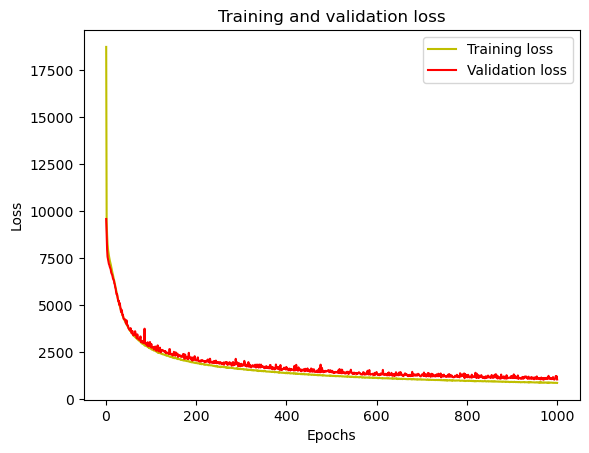

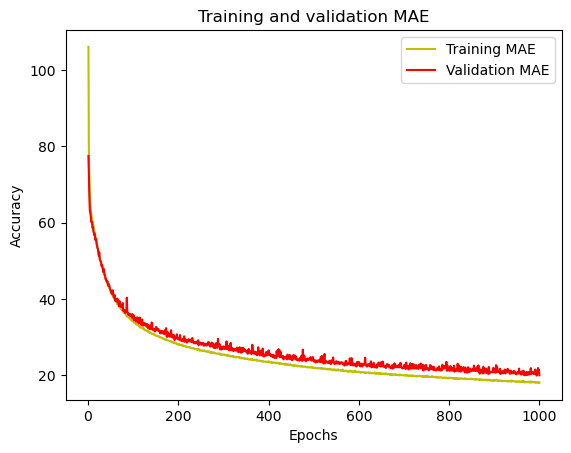

110/110 [==============================] - 0s 2ms/step
Training R^2: 0.9472031740276716
Validation R^2: 0.9299422072186722


In [28]:
epoch_values = [1000]

for epoch in epoch_values: 
    # define the model
    # Experiment with deeper and wider networks

    # Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
    model = Sequential()

    # Dense layers (all connected) are added to the neural network with the specified neuron amount
    # 128 neurons in the 1st hidden layer 
    model.add(Dense(128, input_dim=18, activation='tanh'))

    # 64 neurons in the 2nd hidden layer
    model.add(Dense(64, activation='relu'))

    # Output layer, linear activation function does nothing except adding the results of previous neurons together
    model.add(Dense(1, activation='linear'))

    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    model.summary()

    history = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val] , epochs = epoch)
    #validation_data=[X_test, y_test]

    #plot the training and validation accuracy and loss at each epoch
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs, loss, 'y', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


    acc = history.history['mae']
    val_acc = history.history['val_mae']
    plt.plot(epochs, acc, 'y', label='Training MAE')
    plt.plot(epochs, val_acc, 'r', label='Validation MAE')
    plt.title('Training and validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


    # 1. Obtain predictions for both training and testing sets
    train_predictions = model.predict(X_train_scaled)
    val_predictions = model.predict(X_val_scaled)

    # 2. Calculate R^2 scores
    train_r2 = r2_score(y_train, train_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    print("Training R^2:", train_r2)
    print("Validation R^2:", val_r2)


############################################
#Predict on test data
# predictions = model.predict(X_test_scaled[:5])
# print("Predicted values are: ", predictions)
# print("Real values are: ", y_test[:5])
##############################################

In [29]:
#from keras.callbacks import ModelCheckpoint

from keras.models import load_model

# Save the model
model.save('my_model.h5')

# Load the saved model
loaded_model = load_model('my_model.h5')

c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
additional_epochs = 1000

history_continued = loaded_model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val], epochs=additional_epochs)


Epoch 1/1000
874/874 [==============================] - 4s 4ms/step - loss: 848.0558 - mae: 17.9724 - val_loss: 1140.2611 - val_mae: 21.4730
Epoch 2/1000
874/874 [==============================] - 2s 3ms/step - loss: 866.4266 - mae: 18.1856 - val_loss: 1081.9508 - val_mae: 20.2427
Epoch 3/1000
874/874 [==============================] - 3s 3ms/step - loss: 856.7864 - mae: 18.1611 - val_loss: 1090.4537 - val_mae: 20.6839
Epoch 4/1000
874/874 [==============================] - 3s 3ms/step - loss: 872.2320 - mae: 18.1750 - val_loss: 1083.5747 - val_mae: 20.4139
Epoch 5/1000
874/874 [==============================] - 3s 3ms/step - loss: 855.6863 - mae: 18.1264 - val_loss: 1090.4019 - val_mae: 20.6629
Epoch 6/1000
874/874 [==============================] - 3s 3ms/step - loss: 867.9181 - mae: 18.1804 - val_loss: 1055.5026 - val_mae: 20.3422
Epoch 7/1000
874/874 [==============================] - 3s 3ms/step - loss: 851.9677 - mae: 18.1545 - val_loss: 1050.2537 - val_mae: 20.1179
Epoch 8/1000


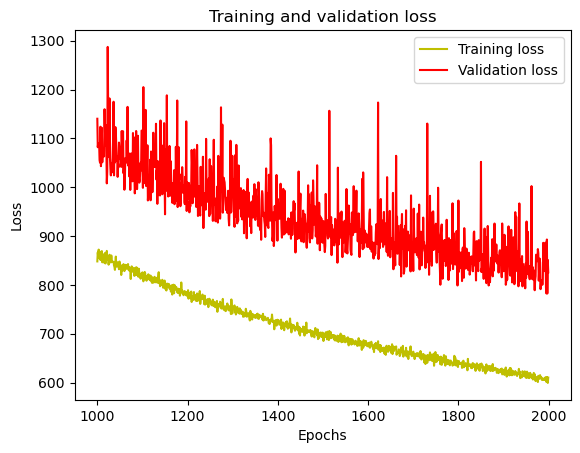

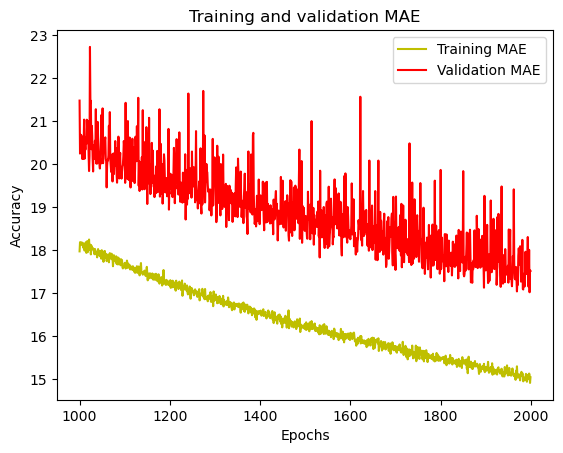

In [35]:
loss2 = history_continued.history['loss']
val_loss2 = history_continued.history['val_loss']
epochs2 = range(1000,2000)
plt.plot(epochs2, loss2, 'y', label='Training loss')
plt.plot(epochs2, val_loss2, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc2 = history_continued.history['mae']
val_acc2 = history_continued.history['val_mae']
plt.plot(epochs2, acc2, 'y', label='Training MAE')
plt.plot(epochs2, val_acc2, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [32]:
# Save the model
loaded_model.save('my_model2.h5')

# Load the saved model
# loaded_model2 = load_model('my_model2.h5')

c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [33]:
# 1. Obtain predictions for both training and testing sets
train_predictions2 = loaded_model.predict(X_train_scaled)
val_predictions2 = loaded_model.predict(X_val_scaled)

# 2. Calculate R^2 scores
train_r2 = r2_score(y_train, train_predictions2)
val_r2 = r2_score(y_val, val_predictions2)

print("Training R^2:", train_r2)
print("Validation R^2:", val_r2)

110/110 [==============================] - 0s 2ms/step
Training R^2: 0.96250350666624
Validation R^2: 0.944539809137011


In [36]:
history_continued2 = loaded_model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val], epochs=additional_epochs)

Epoch 1/1000
874/874 [==============================] - 3s 3ms/step - loss: 612.8067 - mae: 15.1293 - val_loss: 788.4363 - val_mae: 17.1137
Epoch 2/1000
874/874 [==============================] - 3s 3ms/step - loss: 606.9811 - mae: 15.1182 - val_loss: 826.2731 - val_mae: 17.5258
Epoch 3/1000
874/874 [==============================] - 3s 3ms/step - loss: 603.4446 - mae: 14.9939 - val_loss: 832.0584 - val_mae: 17.5757
Epoch 4/1000
874/874 [==============================] - 3s 4ms/step - loss: 597.9232 - mae: 14.9912 - val_loss: 794.6346 - val_mae: 16.9853
Epoch 5/1000
874/874 [==============================] - 3s 3ms/step - loss: 609.0692 - mae: 15.0359 - val_loss: 952.6273 - val_mae: 18.9277
Epoch 6/1000
874/874 [==============================] - 2s 3ms/step - loss: 605.0460 - mae: 15.0183 - val_loss: 832.4291 - val_mae: 17.8383
Epoch 7/1000
874/874 [==============================] - 3s 3ms/step - loss: 603.0575 - mae: 15.0072 - val_loss: 827.8222 - val_mae: 17.5698
Epoch 8/1000
874/874

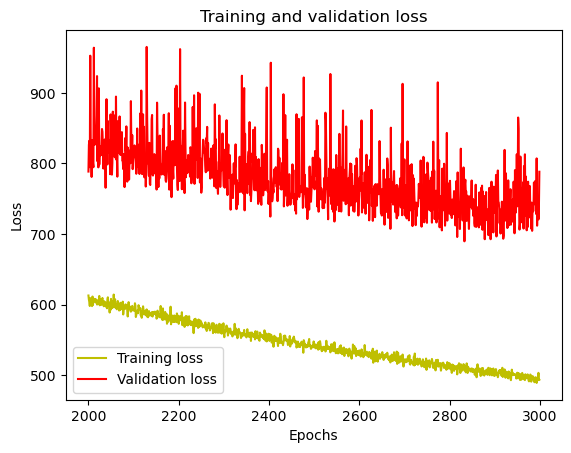

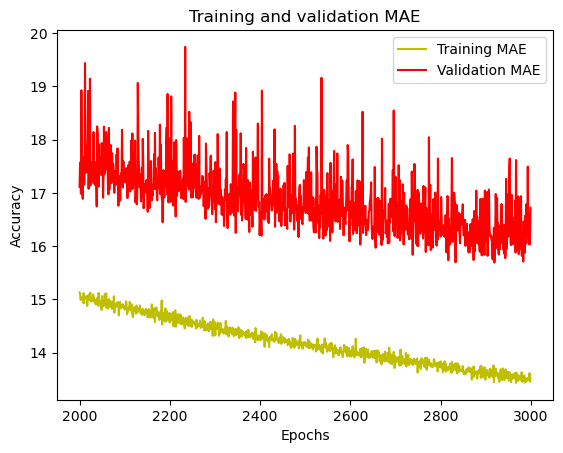

In [37]:
loss3 = history_continued2.history['loss']
val_loss3 = history_continued2.history['val_loss']
epochs3 = range(2000,3000)
plt.plot(epochs3, loss3, 'y', label='Training loss')
plt.plot(epochs3, val_loss3, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc3 = history_continued2.history['mae']
val_acc3 = history_continued2.history['val_mae']
plt.plot(epochs3, acc3, 'y', label='Training MAE')
plt.plot(epochs3, val_acc3, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [38]:
# Save the model
loaded_model.save('my_model3.h5')

c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [39]:
# 1. Obtain predictions for both training and testing sets
train_predictions3 = loaded_model.predict(X_train_scaled)
val_predictions3 = loaded_model.predict(X_val_scaled)

# 2. Calculate R^2 scores
train3_r2 = r2_score(y_train, train_predictions3)
val3_r2 = r2_score(y_val, val_predictions3)

print("Training R^2:", train3_r2)
print("Validation R^2:", val3_r2)

110/110 [==============================] - 0s 2ms/step
Training R^2: 0.9670954699393857
Validation R^2: 0.9470602960962032


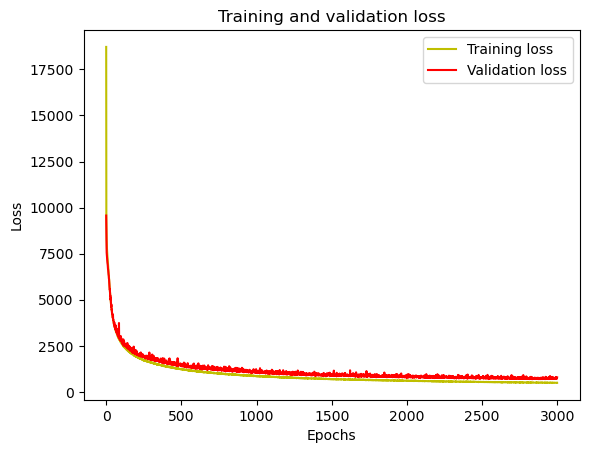

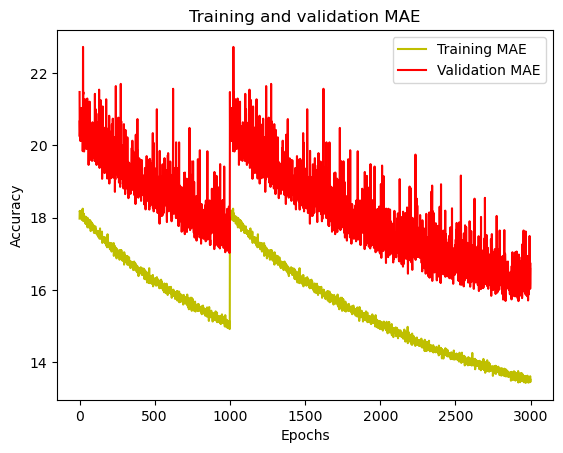

In [51]:
loss_overall = loss + loss2 + loss3;
val_loss_overall = val_loss + val_loss2 + val_loss3

acc_overall = acc + acc2 + acc3
val_acc_overall = val_acc + val_acc2 + val_acc3
epochs_overall = range(3000)

plt.plot(epochs_overall, loss_overall, 'y', label='Training loss')
plt.plot(epochs_overall, val_loss_overall, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(epochs_overall, acc_overall, 'y', label='Training MAE')
plt.plot(epochs_overall, val_acc_overall, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [52]:
test_predictions = loaded_model.predict(X_test_scaled)

test_r2 = r2_score(y_test, test_predictions)

print("Test R^2:", test_r2)

110/110 [==============================] - 0s 2ms/step
Test R^2: 0.9453928302617426
